# Deep SRQ Solver Ablation

Runs DeepSRQ-vs-DeepSRQ configurations per scenario comparing serial and pooled solver backends for PATH and LemkeLCP. All runs use a starting robust epsilon of 0.5 with a linear schedule.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "bimatrix_game":
    BIMATRIX_DIR = ROOT
else:
    BIMATRIX_DIR = ROOT / "discrete_action_space" / "bimatrix_game"
DISCRETE_DIR = BIMATRIX_DIR.parent
for path in (BIMATRIX_DIR, DISCRETE_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from experiment_harness import (
    BASE_SEED,
    configure_path_runtime,
    run_deep_srq_ablation_variants,
    summarize_ablation_timing_rows,
)
from stats_utils import save_training_stats


In [2]:
SCENARIOS = ("scenario1", "scenario3")
N_EPISODES = 3000
EPSILON = 0.5
EPSILON_SCHEDULE = "linear"
PATHWRAP = str(configure_path_runtime(DISCRETE_DIR))
OUTPUT_ROOT = BIMATRIX_DIR / "ablation_runs" / "solver_ablation"
USE_GPU = True
BASE_HP = {
    "sre_solver_workers": 8,
    "sre_num_repeats": 5,
    "sre_include_pure_starts": True,
}

RUN_VARIANTS = (
    # {"label": "serial_path", "solver_name": "path_c"},
    # {"label": "serial_path_pool8", "solver_name": "path_c_pool"},
    {"label": "serial_lemkelcp", "solver_name": "lemkelcp"},
    {"label": "serial_lemkelcp_pool8", "solver_name": "lemkelcp_pool"},
)


In [ ]:
results = run_deep_srq_ablation_variants(
    variants=RUN_VARIANTS,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED,
    pathwrap_path=PATHWRAP,
    output_root=OUTPUT_ROOT,
    use_gpu=USE_GPU,
    write_plots=False,
    default_n_episodes=N_EPISODES,
    default_epsilon_robust_initial=EPSILON,
    default_epsilon_schedule=EPSILON_SCHEDULE,
    default_hyperparameter_overrides=BASE_HP,
)

save_training_stats(OUTPUT_ROOT / "lemkelcp_manifest.txt", results)

for row in summarize_ablation_timing_rows(results):
    print(row)


Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=lemkelcp | seed=2025


scenario1:eps0.5_linear__serial_lemkelcp:lemkelcp: 100%|██████████| 3000/3000 [39:56<00:00,  1.25it/s] 

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/solver_ablation/serial_lemkelcp/scenario1/deepsrq_vs_deepsrq__eps0.5_linear__serial_lemkelcp/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - eps0.5_linear__serial_lemkelcp
Wall clock: 2484.155s (41.40 min)
Episode time:   count=3000, mean=0.827282s (827281.68 us), min=0.000548s, max=3.732141s, std=0.527370s
SRE solve time: count=391598, mean=0.005601s (5601.38 us), min=0.001629s, max=0.024923s, std=0.001800s
Backend solve:  count=391598, mean=0.005122s (5122.49 us), min=0.001201s, max=0.037811s, std=0.002940s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=391598, mean=0.005601s (5601.38 us), min=0.001629s, max=0.024923s, std=0.001800s
    Backend:    count=391598, mean=0.005122s (5122.49 us), min=0.001201s, max=0.037811s, std=0.002940s
    Update:     count=20876, mean=0.082520s (82519.63 us), min=0.034522s, max=1.175420s, std=0.017734s

Reward Summary
Scenario   | Pair          

Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=lemkelcp_pool | seed=2026


scenario1:eps0.5_linear__serial_lemkelcp_pool8:lemkelcp_pool: 100%|██████████| 3000/3000 [23:47<00:00,  2.10it/s]


Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/solver_ablation/serial_lemkelcp_pool8/scenario1/deepsrq_vs_deepsrq__eps0.5_linear__serial_lemkelcp_pool8/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - eps0.5_linear__serial_lemkelcp_pool8
Wall clock: 1478.241s (24.64 min)
Episode time:   count=3000, mean=0.491992s (491991.58 us), min=0.000226s, max=2.493069s, std=0.335993s
SRE solve time: count=409504, mean=0.002787s (2787.15 us), min=0.000581s, max=0.022975s, std=0.002806s
Backend solve:  count=409504, mean=0.006741s (6740.68 us), min=0.001688s, max=0.033148s, std=0.003623s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=409504, mean=0.002787s (2787.15 us), min=0.000581s, max=0.022975s, std=0.002806s
    Backend:    count=409504, mean=0.006741s (6740.68 us), min=0.001688s, max=0.033148s, std=0.003623s
    Update:     count=21772, mean=0.024717s (24716.78 us), min=0.012722s, max=0.049980s, std=0.003581s

Reward Summary
Scenario 

scenario3:eps0.5_linear__serial_lemkelcp:lemkelcp:  71%|███████   | 2129/3000 [49:16<39:31,  2.72s/it]  

In [4]:
def _fmt(value, kind):
    if value is None:
        return "-"
    if kind == "int":
        return f"{int(value):,}"
    if kind == "float1":
        return f"{float(value):,.1f}"
    if kind == "float2":
        return f"{float(value):,.2f}"
    return str(value)


def print_pretty_table(rows, columns):
    rendered = []
    headers = [title for _, title, _ in columns]
    for row in rows:
        rendered.append([_fmt(row.get(key), kind) for key, _, kind in columns])
    widths = [len(header) for header in headers]
    for row in rendered:
        widths = [max(width, len(value)) for width, value in zip(widths, row)]
    header_line = " | ".join(header.ljust(width) for header, width in zip(headers, widths))
    separator = "-+-".join("-" * width for width in widths)
    print(header_line)
    print(separator)
    for row in rendered:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


CASE_LABELS = {
    "serial_path": "Serial PATH",
    "serial_path_pool8": "PATH pool (8)",
    "serial_lemkelcp": "Serial LemkeLCP",
    "serial_lemkelcp_pool8": "LemkeLCP pool (8)",
}


summary_rows = []
for row in summarize_ablation_timing_rows(results):
    stats = results[row["scenario"]][row["variant"]]
    summary_rows.append({
        **row,
        "case": CASE_LABELS.get(row["variant"], row["variant"]),
        "epsilon": stats["epsilon_robust_initial"],
        "schedule": stats["epsilon_schedule"],
        "repeats": stats["hyperparameters"].get("sre_num_repeats"),
        "pure_starts": stats["hyperparameters"].get("sre_include_pure_starts"),
        "solver": stats.get("solver_name"),
    })

summary_rows.sort(key=lambda row: (row["scenario"], row["case"]))

print_pretty_table(
    summary_rows,
    columns=(
        ("scenario", "Scenario", "str"),
        ("epsilon", "Eps0", "float2"),
        ("schedule", "Schedule", "str"),
        ("case", "Case", "str"),
        ("solver", "Solver", "str"),
        ("pure_starts", "Pure", "str"),
        ("repeats", "Repeats", "int"),
        ("env_steps", "Env Steps", "int"),
        ("wall_seconds", "Wall s", "float1"),
        ("steps_per_second", "Steps/s", "float2"),
        ("mean_sre_ms", "SRE ms", "float2"),
        ("mean_backend_ms", "Backend ms", "float2"),
        ("agent1_mean_last", "A1 Last", "float2"),
        ("agent2_mean_last", "A2 Last", "float2"),
    ),
)


Scenario  | Eps0 | Schedule | Case              | Solver        | Pure | Repeats | Env Steps | Wall s  | Steps/s | SRE ms | Backend ms | A1 Last | A2 Last
----------+------+----------+-------------------+---------------+------+---------+-----------+---------+---------+--------+------------+---------+--------
scenario1 | 0.50 | linear   | LemkeLCP pool (8) | lemkelcp_pool | True | 5       | 116,736   | 620.5   | 188.13  | 0.49   | 0.74       | -230.39 | -231.01
scenario1 | 0.50 | linear   | PATH pool (8)     | path_c_pool   | True | 5       | 43,208    | 1,154.9 | 37.41   | 5.54   | 13.78      | 75.56   | 77.56  
scenario1 | 0.50 | linear   | Serial LemkeLCP   | lemkelcp      | True | 5       | 118,629   | 641.0   | 185.08  | 0.56   | 0.14       | -234.41 | -233.68
scenario1 | 0.50 | linear   | Serial PATH       | path_c        | True | 5       | 44,553    | 2,321.5 | 19.19   | 12.19  | 0.50       | 77.91   | 80.22  
scenario3 | 0.50 | linear   | LemkeLCP pool (8) | lemkelcp_pool | True

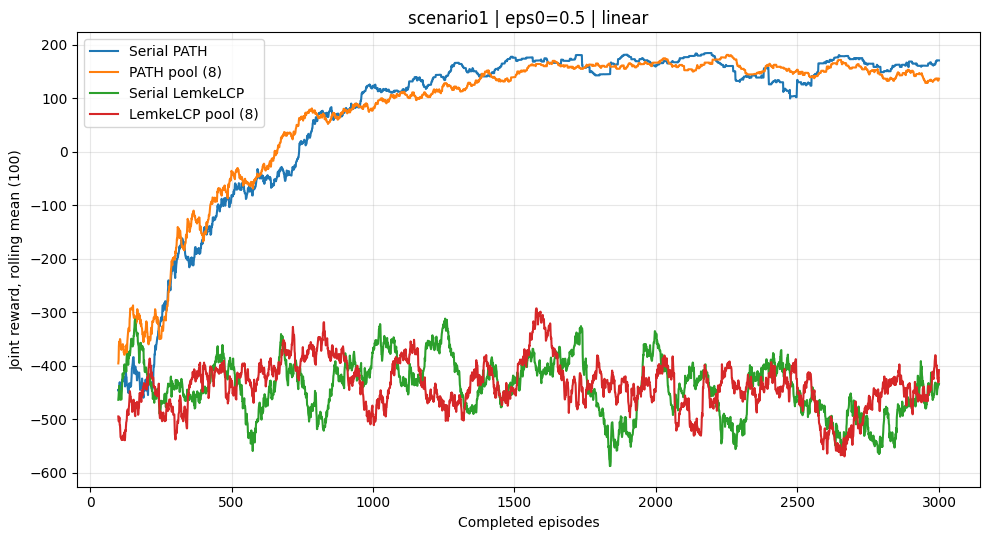

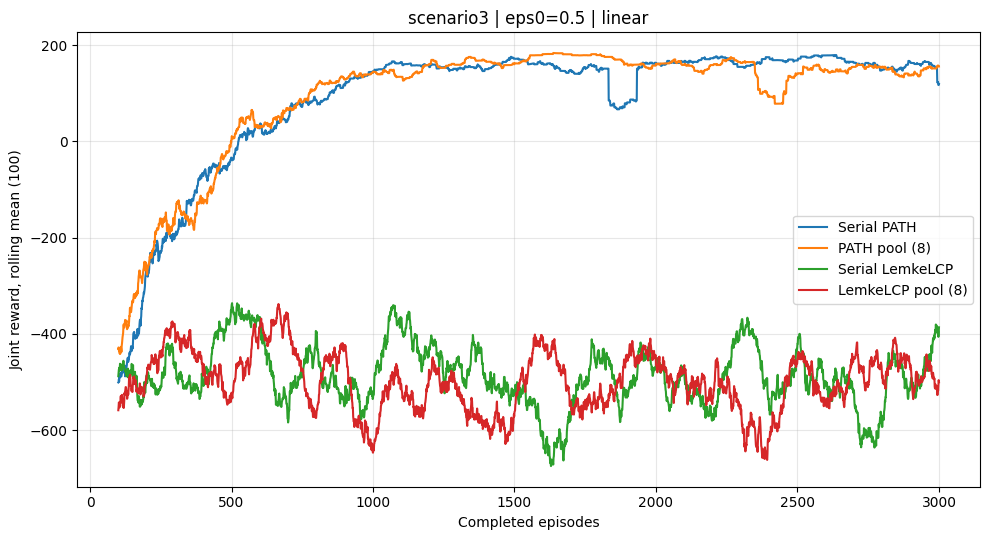

In [5]:
import matplotlib.pyplot as plt
import numpy as np


def rolling_mean(values, window=100):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    window = max(1, min(int(window), values.size))
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


ROLLING_WINDOW = 100

for scenario_key in SCENARIOS:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for variant in RUN_VARIANTS:
        stats = results[scenario_key][variant["label"]]
        rewards = stats["rewards"]
        min_len = min(len(rewards[0]), len(rewards[1]))
        if min_len == 0:
            continue
        joint_reward = np.asarray(rewards[0][:min_len], dtype=float) + np.asarray(rewards[1][:min_len], dtype=float)
        smoothed = rolling_mean(joint_reward, window=ROLLING_WINDOW)
        x = np.arange(smoothed.size) + min(ROLLING_WINDOW, joint_reward.size)
        ax.plot(x, smoothed, label=CASE_LABELS.get(variant["label"], variant["label"]))
    ax.set_title(f"{scenario_key} | eps0={EPSILON:g} | {EPSILON_SCHEDULE}")
    ax.set_xlabel("Completed episodes")
    ax.set_ylabel(f"Joint reward, rolling mean ({ROLLING_WINDOW})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.savefig(OUTPUT_ROOT / f"reward_curves_{scenario_key}.png")
    plt.show()


In [ ]:
# Combined reward curves from previous PATH runs and current LemkeLCP runs
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


COMBINED_VARIANTS = (
    "serial_path",
    "serial_path_pool8",
    "serial_lemkelcp",
    "serial_lemkelcp_pool8",
)

COMBINED_CASE_LABELS = {
    "serial_path": "Serial PATH (previous)",
    "serial_path_pool8": "PATH pool (8, previous)",
    "serial_lemkelcp": "Serial LemkeLCP (new)",
    "serial_lemkelcp_pool8": "LemkeLCP pool (8, new)",
}


def _stats_file_for_variant(scenario_key, variant_label):
    scenario_dir = OUTPUT_ROOT / variant_label / scenario_key
    expected = (
        scenario_dir
        / f"deepsrq_vs_deepsrq__eps{EPSILON:g}_{EPSILON_SCHEDULE}__{variant_label}"
        / "training_stats.txt"
    )
    if expected.exists():
        return expected

    matches = sorted(scenario_dir.glob(f"*__{variant_label}/training_stats.txt"))
    if not matches:
        raise FileNotFoundError(
            f"No training_stats.txt found for {scenario_key}/{variant_label} under {scenario_dir}"
        )
    return matches[-1]


def _load_variant_stats(scenario_key, variant_label):
    stats_path = _stats_file_for_variant(scenario_key, variant_label)
    with open(stats_path, "r") as f:
        stats = json.load(f)
    return stats_path, stats


def _rolling_mean(values, window=100):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    window = max(1, min(int(window), values.size))
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


COMBINED_ROLLING_WINDOW = 100
combined_source_rows = []

for scenario_key in SCENARIOS:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for variant_label in COMBINED_VARIANTS:
        stats_path, stats = _load_variant_stats(scenario_key, variant_label)
        rewards = stats["rewards"]
        min_len = min(len(rewards[0]), len(rewards[1]))
        if min_len == 0:
            continue

        joint_reward = (
            np.asarray(rewards[0][:min_len], dtype=float)
            + np.asarray(rewards[1][:min_len], dtype=float)
        )
        smoothed = _rolling_mean(joint_reward, window=COMBINED_ROLLING_WINDOW)
        x = np.arange(smoothed.size) + min(COMBINED_ROLLING_WINDOW, joint_reward.size)
        ax.plot(x, smoothed, label=COMBINED_CASE_LABELS.get(variant_label, variant_label))

        combined_source_rows.append({
            "scenario": scenario_key,
            "variant": variant_label,
            "solver": stats.get("solver_name"),
            "episodes": min_len,
            "stats_path": str(stats_path),
        })

    ax.set_title(
        f"{scenario_key} | PATH previous + LemkeLCP current | eps0={EPSILON:g} | {EPSILON_SCHEDULE}"
    )
    ax.set_xlabel("Completed episodes")
    ax.set_ylabel(f"Joint reward, rolling mean ({COMBINED_ROLLING_WINDOW})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(OUTPUT_ROOT / f"reward_curves_combined_path_previous_lemke_current_{scenario_key}.png")
    plt.show()

for row in combined_source_rows:
    print(row)
